In [1]:
import json

with open("client_ip.json", "r") as f:
    client_ip = json.load(f)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
def lstm_vector(ts1,sizes1,ts2,sizes2,voip=False):
    #determine direction
    if voip:
        src_ts = ts1
        src_sizes = sizes1
        dst_ts = ts2
        dst_sizes = sizes2
    else:
        if ts1[0]<ts2[0]:
            src_ts = ts1
            src_sizes = sizes1
            dst_ts = ts2
            dst_sizes = sizes2
        else:
            src_ts = ts2
            src_sizes = sizes2
            dst_ts = ts1
            dst_sizes = sizes1
    array = []
    j = 0 #src
    k = 0 #dst
    min_val = min(src_ts[0],dst_ts[0])
    length = len(src_ts)+len(dst_ts)
    for i in range(40):
        if j>=len(src_ts) and k>=len(dst_ts):
            break
        if j>=len(src_ts):
            array.append([round(dst_ts[k]-min_val,6),-dst_sizes[k]])
            k+=1
        elif k >= len(dst_ts):
            array.append([round(src_ts[j]-min_val,6),src_sizes[j]]) 
            j+=1
        elif src_ts[j]<=dst_ts[k]:
            array.append([round(src_ts[j]-min_val,6),src_sizes[j]]) 
            j+=1
        else:
            array.append([round(dst_ts[k]-min_val,6),-dst_sizes[k]])
            k+=1
    # for i in range(WINDOW-length):
    #      array.append([0,0])
    array = np.array(array)
    X = array.reshape(-1,2)
    return X

In [3]:
WINDOW=50
def seq_50(ts1,sizes1,ts2,sizes2):
    #determine direction
    if ts1[0]<ts2[0]:
        src_ts = ts1
        src_sizes = sizes1
        dst_ts = ts2
        dst_sizes = sizes2
    else:
        src_ts = ts2
        src_sizes = sizes2
        dst_ts = ts1
        dst_sizes = sizes1
    array = []
    j = 0 #src
    k = 0 #dst
    min_val = min(src_ts[0],dst_ts[0])
    for i in range(WINDOW):
        if j>=len(src_ts) and k>=len(dst_ts):
            break
        if j>=len(src_ts):
            array.append([round(dst_ts[k]-min_val,6),-dst_sizes[k]])
            k+=1
        elif k >= len(dst_ts):
            array.append([round(src_ts[j]-min_val,6),src_sizes[j]]) 
            j+=1
        elif src_ts[j]<=dst_ts[k]:
            array.append([round(src_ts[j]-min_val,6),src_sizes[j]]) 
            j+=1
        else:
            array.append([round(dst_ts[k]-min_val,6),-dst_sizes[k]])
            k+=1
    for i in range(WINDOW-len(array)):
         array.append([0,0])
    array = np.array(array)
    X = array.reshape(-1,2)
    return X

In [4]:
def check_strings_in_classname(classname):
    keywords = {
    "web": 0, "video": 1, "social": 2, "email": 3,"docs":7
    }
    for keyword in keywords:
        if keyword in classname:
            return keywords[keyword] 
    return None

In [5]:
import os
import csv
import tensorflow as tf
path2 = os.path.abspath('..')
folder_path = path2+"/labeled_train"
X_train = []
y_train = []
voip = []
gaming = []
web = []
video = []
social = []
email = []
doc = []
microsoft = []
chat = []
background = []

In [6]:
import json
def traffic_csv_converter(file_path):
    X_train = []
    y_train = []
    with open(file_path, 'r') as csv_file:
        reader = csv.reader(csv_file)
        filename = os.path.splitext(os.path.basename(file_path))[0]
        flow_val = {}
        class_val = {}
        paired_keys = set()
        for i, row in enumerate(reader):
            class_name = row[0]
            src_ip = row[1]
            src_port = row[2]
            dst_ip = row[3]
            dst_port = row[4]
            length = int(row[7])
            ts = np.array(row[8:8+length], dtype=float)
            sizes = np.array(row[9+length:], dtype=int)
            key = (src_ip, src_port, dst_ip, dst_port)
            reverse_key = (dst_ip, dst_port, src_ip, src_port)
            if reverse_key in flow_val:
                # Found the reverse flow
                opposite_ts, opposite_sizes = flow_val.pop(reverse_key)
                paired_keys.add(key)
                paired_keys.add(reverse_key)
                if len(opposite_ts) + len(ts) < 40: #flow too small
                    continue
                if "voip" in file_path and class_name =="voip":
                    if reverse_key[0] in client_ip:
                        src_ts, src_sizes = opposite_ts, opposite_sizes
                        dst_ts, dst_sizes = ts, sizes
                    else:
                        src_ts, src_sizes = ts, sizes
                        dst_ts, dst_sizes = opposite_ts, opposite_sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes,True)
                    v = seq_50(src_ts, src_sizes, dst_ts, dst_sizes)
                else:
                    src_ts, src_sizes = opposite_ts, opposite_sizes
                    dst_ts, dst_sizes = ts, sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes)
                    v = seq_50(src_ts, src_sizes, dst_ts, dst_sizes)
                if "voip" in file_path and class_name == "voip":
                    voip.append(v)
                    y_train.append(7)
                elif "gaming" in file_path:
                    gaming.append(v)
                    y_train.append(8)
                elif class_name == "web":
                    web.append(v)
                    y_train.append(0)
                elif class_name == "video":
                    video.append(v)
                    y_train.append(1)
                elif class_name == "social":
                    social.append(v)
                    y_train.append(2)
                elif class_name == "email":
                    email.append(v)
                    y_train.append(3)
                elif class_name == "doc":
                    doc.append(v)
                    y_train.append(4)
                elif class_name == "microsoft":
                    microsoft.append(v)
                    y_train.append(5)
                elif class_name == "chat":
                    chat.append(v)
                    y_train.append(6)
                else: #background_flow
                    background.append(v)
                    y_train.append(9)
                X_train.append(x)
            else:
                # Save forward direction flow
                flow_val[key] = (ts, sizes)
                class_val[key] = class_name
    for key, value in flow_val.items():
        if key[1] == "5353":
            continue
        if len(value[0]) >= 40:
            if "voip" in file_path:
                ts = value[0][:40]
                sizes = value[1][:40]
                if key[0] in client_ip:
                    sizes = value[1][:40]
                else:
                    sizes = -value[1][:40]
                v = np.stack((ts, sizes), axis=1)
                X_train.append(v)
                if class_val[key] == "voip": #if the flow is unique
                    y_train.append(7)
                else:
                    y_train.append(9) #if the flow is background
                
                ts = value[0][:50]
                if key[0] in client_ip:
                    sizes = value[1][:50]
                else:
                    sizes = -value[1][:50]
                if len(ts)<50:
                    pad = 50 - len(ts)
                    ts    = np.pad(ts,    (0, pad), mode="constant", constant_values=0)
                    sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                    
                v = np.stack((ts, sizes), axis=1)
                if class_val[key] == "voip":
                    voip.append(v)
            elif "gaming" in file_path:
                ts = value[0][:40]
                sizes = value[1][:40]
                v = np.stack((ts, sizes), axis=1)
                X_train.append(v)
                y_train.append(8)
                
                ts = value[0][:50]
                sizes = value[1][:50]
                if len(ts)<50:
                    pad = 50 - len(ts)
                    ts    = np.pad(ts,    (0, pad), mode="constant", constant_values=0)
                    sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                v = np.stack((ts, sizes), axis=1)
                gaming.append(v)
            
            
    return X_train, y_train
def iterate_over_files_in_directory(directory):
    for file_name in os.listdir(directory):
        if file_name.endswith(".csv"):  # You can adjust the file extension if needed
            file_path = os.path.join(directory, file_name)
            yield file_path


In [7]:
docs_path = folder_path + "/docs"
for file_path in iterate_over_files_in_directory(docs_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
web_path = folder_path + "/web"
for file_path in iterate_over_files_in_directory(web_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
chat_path = folder_path + "/chat"
for file_path in iterate_over_files_in_directory(chat_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
social_path = folder_path + "/social"
for file_path in iterate_over_files_in_directory(social_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
video_path = folder_path + "/video"
for file_path in iterate_over_files_in_directory(video_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
voip_path = folder_path + "/voip"
for file_path in iterate_over_files_in_directory(voip_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
gaming_path = folder_path + "/gaming"
for file_path in iterate_over_files_in_directory(gaming_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
email_path = folder_path + "/email"
for file_path in iterate_over_files_in_directory(email_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)

In [ ]:
import numpy as np
X_dataset = np.array(X_train)
y_dataset = np.array(y_train)

In [7]:
from scipy.stats import truncnorm
def translation(X):
    arrival_times = X
    n,time_steps,features = arrival_times.shape
    for i in range(n):
        threshold_indices = [2,4,6,8,10] 
        max_n =np.random.choice(threshold_indices) 
        n = np.random.randint(1, max_n + 1)  # Shift 1 to `max_n` packets
        t = np.random.randint(0, 40) 
        direction = np.random.choice(['left', 'right'])
        if direction == 'left':
            total_length = arrival_times.shape[1]
            start_index = t-n
            if start_index < 0: 
                valid_portion = arrival_times[i, t - start_index:50]
                assigned_value = valid_portion.shape[0]
                arrival_times[i, 0:assigned_value] = valid_portion
                arrival_times[i, assigned_value+1:] = 0 
            else:
                valid_portion = arrival_times[i, t:(50)]
                assigned_value = arrival_times[i, start_index:50].shape
                zeros = np.zeros((assigned_value[0]-valid_portion.shape[0],2))
                arrival_times[i, start_index:50] = np.concatenate((valid_portion, zeros))  # bounded to the right by 50
            
        else:
            t_val = arrival_times[i, t] 
            last_index = min(t + n, 40) 
            first_val = min(last_index + n, 40)  
            num_to_shift = last_index - t  
            available_space = 40 - first_val 
            if num_to_shift > 0:
                shift_amount = min(num_to_shift, available_space)
                arrival_times[i, first_val:first_val + shift_amount] = arrival_times[i, t:t + shift_amount]
            arrival_times[i, t:last_index] = t_val
    return arrival_times
def gaussian_noise(X, noise_std=0.05):
    X_augmented = X
    
    absolute = np.abs(X_augmented)
    absolute = np.diff(absolute[:, :, 0], axis=1)
    absolute_reshaped = absolute.reshape(X_augmented.shape[0], 39, 1)
    
    min_values = -absolute_reshaped[:, :, 0]
    lower_bound = (min_values)/noise_std
    upper_bound = np.inf 
    noise = truncnorm.rvs(lower_bound,upper_bound,loc=0.0, scale=noise_std, size=absolute_reshaped[:, :, 0].shape)
    cumulative_noise = np.cumsum(noise, axis=1)
    
    positive_mask = X_augmented[:, 1:, 0] > 0
    X_augmented[:, 1:, 0][positive_mask] += cumulative_noise[positive_mask]
    negative_mask = X_augmented[:, 1:, 0] < 0
    X_augmented[:, 1:, 0][negative_mask] -= cumulative_noise[negative_mask]
    return X_augmented

In [12]:
for i in range(9):
    if i == 0:
        sample = web
    elif i == 1:
        sample = video
    elif i == 2:
        sample = social
    elif i == 3:
        sample = email
    elif i == 4:
        sample = doc
    elif i == 5:
        sample = microsoft
    elif i == 6:
        sample = chat
    elif i == 7:
        sample = voip
    elif i == 8:
        sample = gaming
    indices = tf.range(sample.shape[0])
    value = len(sample)
    sampled_indices = np.random.choice(indices, max_val-value, replace=True)
    sampled_X = sample[sampled_indices]
    augmented = translation(sampled_X)
    augmented = augmented[:, :40, :]
    X_dataset = np.vstack((X_dataset,augmented))
    y = np.array([i]*(max_val-value))
    y_dataset = np.concatenate((y_dataset,y))

W0000 00:00:1750630211.703957 3011086 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [13]:
counter = Counter(y_dataset)
counts = [counter.get(i, 0) for i in range(8)]

In [14]:
counts

[24535, 24535, 24535, 24535, 24535, 24535, 24535, 24535]

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_dataset, y_dataset, test_size=0.2, random_state=42)


In [ ]:
np.save('X_train.npy', X_train)
np.save('y_train.npy', y_train)
np.save('X_val.npy', X_val)
np.save('y_val.npy', y_val)

In [10]:
X_dataset = np.concatenate((X_train,X_val))
y_dataset = np.concatenate((y_train,y_val))

In [11]:
features = 40
input_shape = (features,2)

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow.keras.backend as K
from tensorflow.keras import layers, models,regularizers
from encoders import lstm_encoder,cnn_encoder,transformer_encoder,fsnet_encoder

def crc_loss(temperature=0.07):
    def loss_fn(labels, features):
        # 1) L₂‑normalize
        features = tf.math.l2_normalize(features, axis=1)
        batch_size = tf.shape(features)[0]

        # 2) Pairwise logits scaled by temperature
        logits = tf.matmul(features, features, transpose_b=True) / temperature
        # numeric stability
        logits -= tf.reduce_max(logits, axis=1, keepdims=True)

        # 3) Build positive mask
        labels = tf.reshape(labels, [batch_size, 1])
        mask = tf.cast(tf.equal(labels, tf.transpose(labels)), tf.float32)
        # remove self
        diag = tf.eye(batch_size)
        mask_no_self = mask - diag

        # 4) Hide self‑similarities in softmax
        LARGE_NUM = 1e9
        logits -= diag * LARGE_NUM

        # 5) Log‑probs
        log_prob = logits - tf.reduce_logsumexp(logits, axis=1, keepdims=True)

        # 6) Sum log‑prob over positives, and count them
        sum_log_prob_pos = tf.reduce_sum(mask_no_self * log_prob, axis=1)
        num_positives   = tf.reduce_sum(mask_no_self,     axis=1)

        # 7) Only keep anchors that actually have ≥1 positive
        valid_mask      = num_positives > 0
        sum_log_prob_pos = tf.boolean_mask(sum_log_prob_pos, valid_mask)
        num_positives    = tf.boolean_mask(num_positives,    valid_mask)

        # 8) Mean log‑prob for each valid anchor
        mean_log_prob_pos = sum_log_prob_pos / num_positives

        # 9) Final loss
        loss = -tf.reduce_mean(mean_log_prob_pos)
        return loss

    return loss_fn


# encoder = fsnet_encoder()
# encoder = cnn_encoder()
# encoder = transformer_encoder()
encoder = lstm_encoder((40,2))
crc_loss_fn = crc_loss(temperature=0.07)
encoder.compile(optimizer='adam', loss=crc_loss_fn)


W0000 00:00:1753964254.526524 2015906 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True, verbose=1)
model_checkpoint = ModelCheckpoint('lstm_contrastive_loss.weights.h5', save_best_only=True, monitor='val_loss', verbose=1, save_weights_only=True)
# model_checkpoint = ModelCheckpoint('50fsnet_contrastive_loss.weights.h5', save_best_only=True, monitor='val_loss', verbose=1, save_weights_only=True)



In [ ]:
encoder.fit(X_train, y_train, epochs=1000, batch_size=128, validation_data=(X_val, y_val),callbacks=[early_stopping, model_checkpoint])

Epoch 1/1000
1159/1534 ━━━━━━━━━━━━━━━━━━━━ 1:11 190ms/step - loss: 4.0495

In [15]:
encoder.load_weights('lstm_contrastive_loss.weights.h5')

In [18]:
embeddings = encoder.predict(X_dataset)

7668/7668 ━━━━━━━━━━━━━━━━━━━━ 119s 15ms/step


In [19]:
web_index = np.where(y_dataset==0)[0]
video_index = np.where(y_dataset==1)[0]
social_index = np.where(y_dataset==2)[0]
email_index = np.where(y_dataset==3)[0]
doc_index = np.where(y_dataset==4)[0]
microsoft_index = np.where(y_dataset==5)[0]
chat_index = np.where(y_dataset==6)[0]
voip_index = np.where(y_dataset==7)[0]
gaming_index = np.where(y_dataset==8)[0]
background_index = np.where(y_dataset==9)[0]

In [20]:
def cosine_similarity(vectors, reference):
    vectors_norm = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
    reference_norm = reference / np.linalg.norm(reference)
    return np.dot(vectors_norm, reference_norm)
def normalize(vectors):
    return vectors / np.linalg.norm(vectors, axis=1, keepdims=True)


In [21]:
embeddings = normalize(embeddings)
web_embeddings               = embeddings[web_index]
video_embeddings             = embeddings[video_index]
social_embeddings            = embeddings[social_index]
email_embeddings             = embeddings[email_index]
doc_embeddings               = embeddings[doc_index]
microsoft_cloud_embeddings   = embeddings[microsoft_index]
chat_embeddings              = embeddings[chat_index]
voip_embeddings              = embeddings[voip_index]
gaming_embeddings            = embeddings[gaming_index]
background_embeddings            = embeddings[background_index]
#web
web_centroid = np.mean(web_embeddings, axis=0)
all_web_similarities = cosine_similarity(embeddings,web_centroid)

#social
social_centroid = np.mean(social_embeddings, axis=0)
all_social_similarities = cosine_similarity(embeddings,social_centroid)

#email
email_centroid = np.mean(email_embeddings, axis=0)
all_email_similarities = cosine_similarity(embeddings,email_centroid)

#video
video_centroid = np.mean(video_embeddings, axis=0)
all_video_similarities = cosine_similarity(embeddings,video_centroid)

#microsoft
microsoft_cloud_centroid = np.mean(microsoft_cloud_embeddings, axis=0)
all_microsoft_cloud_similarities = cosine_similarity(embeddings,microsoft_cloud_centroid)

# document
doc_centroid                    = np.mean(doc_embeddings, axis=0)
all_doc_similarities            = cosine_similarity(embeddings, doc_centroid)

# chat
chat_centroid                   = np.mean(chat_embeddings, axis=0)
all_chat_similarities           = cosine_similarity(embeddings, chat_centroid)

# VoIP
voip_centroid                   = np.mean(voip_embeddings, axis=0)
all_voip_similarities           = cosine_similarity(embeddings, voip_centroid)

# gaming
gaming_centroid                 = np.mean(gaming_embeddings, axis=0)
all_gaming_similarities         = cosine_similarity(embeddings, gaming_centroid)

# gaming
background_centroid                 = np.mean(background_embeddings, axis=0)
all_background_similarities         = cosine_similarity(embeddings, background_centroid)

In [22]:
from sklearn.mixture import GaussianMixture
all_features = np.column_stack([
    all_web_similarities,          # column 0
    all_social_similarities,       # column 1
    all_email_similarities,        # column 2
    all_video_similarities,        # column 3
    all_microsoft_cloud_similarities,  # column 4
    all_doc_similarities,          # column 5
    all_chat_similarities,         # column 6
    all_voip_similarities,         # column 7
    all_gaming_similarities,       # column 8
    all_background_similarities    # column 9
])  # shape = (n_samples, 10)

# 2) Fit your 10-component Gaussian Mixture
gmm10 = GaussianMixture(
    n_components=10,
    covariance_type='full',
    init_params='kmeans',
    max_iter=500,
    random_state=0
)
gmm10.fit(all_features)



GaussianMixture(max_iter=500, n_components=10, random_state=0)

In [23]:
from collections import Counter

labels_train = gmm10.predict(all_features)   # array of ints in [0..9], shape (n_samples,)

category_names = [
    "web","social","email","video","ms_cloud",
    "doc","chat","voip","gaming","background"
]

cluster_label_map = {}
for k in range(gmm10.n_components):
    # indices of train samples assigned to cluster k
    idxs = np.where(labels_train == k)[0]
    if len(idxs) == 0:
        # no training points in this cluster
        cluster_label_map[k] = None  
    else:
        # find the most common true label among those points
        true_labels = [y_dataset[i] for i in idxs]
        most_common_label = Counter(true_labels).most_common(1)[0][0]
        cluster_label_map[k] = most_common_label


In [24]:
cluster_label_map

{0: np.int64(5),
 1: np.int64(0),
 2: np.int64(8),
 3: np.int64(3),
 4: np.int64(6),
 5: np.int64(7),
 6: np.int64(1),
 7: np.int64(2),
 8: np.int64(4),
 9: np.int64(9)}

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
cluster_to_true_list = {}
for k in sorted(cluster_label_map.keys()):
    idxs = np.where(labels_train == k)[0]
    true_labels_in_k = [int(y_dataset[i]) for i in idxs]
    cluster_to_true_list[k] = true_labels_in_k

# ─── 2) Sort cluster indices by their majority predicted label (None last) ────
sorted_clusters = sorted(
    cluster_to_true_list.keys(),
    key=lambda k: (
        cluster_label_map[k] is None,           # empty clusters ⇒ True ⇒ goes last
        cluster_label_map[k] if cluster_label_map[k] is not None else -1, 
        k                                        # tie‐breaker: lower cluster ID first
    )
)

# ─── 3) Print a summary in that order ────────────────────────────────────────
for k in sorted_clusters:
    true_list = cluster_to_true_list[k]
    majority = cluster_label_map[k]
    if not true_list:
        print(f"Cluster {k}:  (majority predicted label = {majority}) → no points assigned.")
        continue

    counts = Counter(true_list)
    total = len(true_list)
    print(f"\nCluster {k}:  (majority predicted label = {majority})")
    print(f"  Total points in cluster: {total}")
    print("  Breakdown of true‐labels:")
    for true_label, cnt in counts.most_common():
        pct = (cnt / total) * 100
        print(f"    True label {true_label}: {cnt} points ({pct:.2f}%)")


Cluster 1:  (majority predicted label = 0)
  Total points in cluster: 23341
  Breakdown of true‐labels:
    True label 0: 23248 points (99.60%)
    True label 9: 85 points (0.36%)
    True label 2: 6 points (0.03%)
    True label 1: 2 points (0.01%)

Cluster 6:  (majority predicted label = 1)
  Total points in cluster: 23503
  Breakdown of true‐labels:
    True label 1: 23484 points (99.92%)
    True label 9: 19 points (0.08%)

Cluster 7:  (majority predicted label = 2)
  Total points in cluster: 23955
  Breakdown of true‐labels:
    True label 2: 23917 points (99.84%)
    True label 9: 25 points (0.10%)
    True label 0: 12 points (0.05%)
    True label 1: 1 points (0.00%)

Cluster 3:  (majority predicted label = 3)
  Total points in cluster: 23748
  Breakdown of true‐labels:
    True label 3: 23729 points (99.92%)
    True label 9: 12 points (0.05%)
    True label 4: 6 points (0.03%)
    True label 0: 1 points (0.00%)

Cluster 8:  (majority predicted label = 4)
  Total points in clu

In [26]:
log_likes = gmm10.score_samples(all_features)
cutoff = np.percentile(log_likes, 5)
# cutoff = np.percentile(log_likes, 10)

In [27]:
X_test = []
y_test = []
domain_name = []

In [28]:
def test_traffic_csv_converter(file_path):
    X_train = []
    y_train = []
    with open(file_path, 'r') as csv_file:
        reader = csv.reader(csv_file)
        filename = os.path.splitext(os.path.basename(file_path))[0]
        flow_val = {}
        class_val = {}
        paired_keys = set()
        for i, row in enumerate(reader):
            domainname = row[0]
            class_name = row[1]
            src_ip = row[2]
            src_port = row[3]
            dst_ip = row[4]
            dst_port = row[5]
            length = int(row[8])
            ts = np.array(row[9:9+length], dtype=float)
            sizes = np.array(row[10+length:], dtype=int)
            key = (src_ip, src_port, dst_ip, dst_port)
            reverse_key = (dst_ip, dst_port, src_ip, src_port)
            if reverse_key in flow_val:
                # Found the reverse flow
                opposite_ts, opposite_sizes = flow_val.pop(reverse_key)
                paired_keys.add(key)
                paired_keys.add(reverse_key)
                if len(opposite_ts) + len(ts) < 40: #flow too small
                    continue
                if "voip" in file_path and class_name =="voip":
                    if reverse_key[0] in client_ip:
                        src_ts, src_sizes = opposite_ts, opposite_sizes
                        dst_ts, dst_sizes = ts, sizes
                    else:
                        src_ts, src_sizes = ts, sizes
                        dst_ts, dst_sizes = opposite_ts, opposite_sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes,True)
                    v = seq_50(src_ts, src_sizes, dst_ts, dst_sizes)
                else:
                    src_ts, src_sizes = opposite_ts, opposite_sizes
                    dst_ts, dst_sizes = ts, sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes)
                    v = seq_50(src_ts, src_sizes, dst_ts, dst_sizes)
                if "voip" in file_path and class_name == "voip":
                    y_train.append(7)
                elif "gaming" in file_path:
                    y_train.append(8)
                elif class_name == "web":
                    y_train.append(0)
                elif class_name == "video":
                    y_train.append(1)
                elif class_name == "social":
                    y_train.append(2)
                elif class_name == "email":
                    y_train.append(3)
                elif class_name == "doc":
                    y_train.append(4)
                elif class_name == "microsoft":
                    y_train.append(5)
                elif class_name == "chat":
                    y_train.append(6)
                else: #background_flow
                    y_train.append(9)
                X_train.append(x)
                domain_name.append(domainname)
            else:
                # Save forward direction flow
                flow_val[key] = (ts, sizes)
                class_val[key] = class_name
    for key, value in flow_val.items():
        if key[1] == "5353":
            continue
        if len(value[0]) >= 40:
            if "voip" in file_path:
                ts = value[0][:40]
                sizes = value[1][:40]
                if key[0] in client_ip:
                    sizes = value[1][:40]
                else:
                    sizes = -value[1][:40]
                v = np.stack((ts, sizes), axis=1)
                # X_train.append(v)
                if class_val[key] == "voip": #if the flow is unique
                    X_train.append(v)
                    y_train.append(7)
                    domain_name.append("voip")

                else:
                    X_train.append(v)
                    y_train.append(9) #if the flow is background
                    domain_name.append("background")
            elif "gaming" in file_path:
                ts = value[0][:40]
                sizes = value[1][:40]
                v = np.stack((ts, sizes), axis=1)
                X_train.append(v)
                y_train.append(8)
                domain_name.append("gaming")
    return X_train, y_train

In [29]:
folder_path = os.path.abspath('..')+"/domain_labeled_test"
docs_path = folder_path + "/docs"
for file_path in iterate_over_files_in_directory(docs_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
web_path = folder_path + "/web"
for file_path in iterate_over_files_in_directory(web_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
chat_path = folder_path + "/chat"
for file_path in iterate_over_files_in_directory(chat_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
social_path = folder_path + "/social"
for file_path in iterate_over_files_in_directory(social_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
video_path = folder_path + "/video"
for file_path in iterate_over_files_in_directory(video_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
voip_path = folder_path + "/voip"
for file_path in iterate_over_files_in_directory(voip_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
gaming_path = folder_path + "/gaming"
for file_path in iterate_over_files_in_directory(gaming_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
email_path = folder_path + "/email"
for file_path in iterate_over_files_in_directory(email_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)

In [30]:
X_test = np.array(X_test)

In [31]:
test_embeddings = encoder.predict(X_test)
test_embeddings = normalize(test_embeddings)

352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step


In [32]:
test_web_similarities = cosine_similarity(test_embeddings, web_centroid)
test_social_similarities = cosine_similarity(test_embeddings, social_centroid)
test_email_similarities = cosine_similarity(test_embeddings, email_centroid)
test_video_similarities = cosine_similarity(test_embeddings, video_centroid)
test_microsoft_cloud_similarities = cosine_similarity(test_embeddings, microsoft_cloud_centroid)
test_doc_similarities             = cosine_similarity(test_embeddings, doc_centroid)
test_chat_similarities            = cosine_similarity(test_embeddings, chat_centroid)
test_voip_similarities            = cosine_similarity(test_embeddings, voip_centroid)
test_gaming_similarities          = cosine_similarity(test_embeddings, gaming_centroid)
test_background_similarities          = cosine_similarity(test_embeddings, background_centroid)

In [33]:
test_features = np.column_stack([
    test_web_similarities,          # column 0
    test_social_similarities,       # column 1
    test_email_similarities,        # column 2
    test_video_similarities,        # column 3
    test_microsoft_cloud_similarities,  # column 4
    test_doc_similarities,          # column 5
    test_chat_similarities,         # column 6
    test_voip_similarities,         # column 7
    test_gaming_similarities,       # column 8
    test_background_similarities    # column 9
])  # shape = (n_samples, 10)

In [34]:
labels_test = gmm10.predict(test_features)

# b) map each cluster to a predicted label index
y_pred = [
    cluster_label_map[k] if cluster_label_map[k] is not None else -1
    for k in labels_test
]


In [35]:
cluster_label_map

{0: np.int64(5),
 1: np.int64(0),
 2: np.int64(8),
 3: np.int64(3),
 4: np.int64(6),
 5: np.int64(7),
 6: np.int64(1),
 7: np.int64(2),
 8: np.int64(4),
 9: np.int64(9)}

In [36]:
np.unique(y_pred)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
macro_f1 = round(f1_score(y_test, y_pred, average='macro'), 2)
accuracy = round(accuracy_score(y_test, y_pred), 2)
average_f1 = round(f1_score(y_test, y_pred, average='weighted'), 2)
# precision = precision_score(y_test_categorical, y_pred, average=None)
# recall = recall_score(y_test_categorical, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)
conf_matrix = confusion_matrix(y_test, y_pred)

# Print or use the evaluation metrics as needed
print(f'Macro Average F1 Score: {macro_f1}')
print(f'Accuracy: {accuracy}')
print(f'Weighted Average F1 Score: {average_f1}')

Macro Average F1 Score: 0.85
Accuracy: 0.95
Weighted Average F1 Score: 0.95


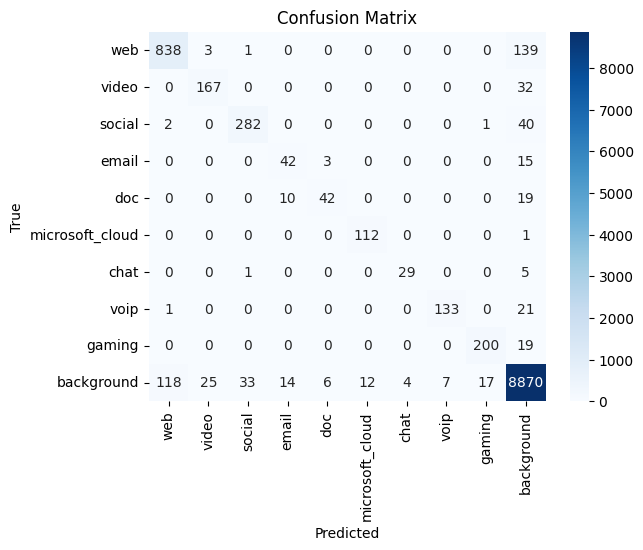

In [38]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['web','video','social','email','doc','microsoft_cloud','chat','voip','gaming','background'], yticklabels=['web','video','social','email','doc','microsoft_cloud','chat','voip','gaming','background'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

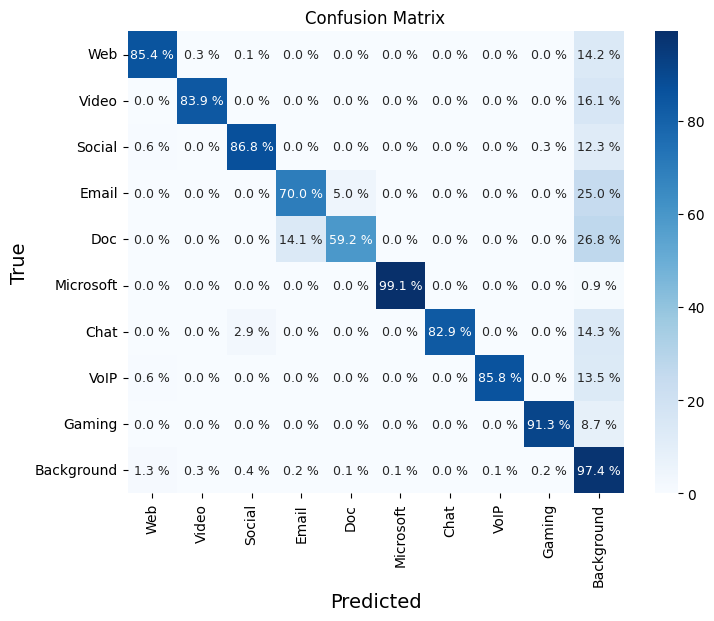

In [39]:
conf_matrix_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Microsoft","Chat","VoIP","Gaming","Background"]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
annot_kws = {"size": 9}
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws=annot_kws)
for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)  
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.show()

In [48]:
y_pred = np.array(y_pred)
y_test = np.array(y_test)

In [49]:
per_class_acc = {}
for cls in np.unique(y_test):
    # find all positions where the true label is cls
    idx = np.where(y_test == cls)[0]
    # fraction of those that were correctly predicted
    per_class_acc[cls] = np.mean(y_pred[idx] == y_test[idx]) * 100

# print results
for cls, acc in per_class_acc.items():
    print(f"Label {cls}: {acc:.2f}% correct")

Label 0: 85.42% correct
Label 1: 83.92% correct
Label 2: 86.77% correct
Label 3: 70.00% correct
Label 4: 59.15% correct
Label 5: 99.12% correct
Label 6: 82.86% correct
Label 7: 85.81% correct
Label 8: 91.32% correct
Label 9: 97.41% correct


In [50]:
total = len(y_test)

for cls in np.unique(y_test):
    idx       = np.where(y_test == cls)[0]
    count_i   = len(idx)
    correct_i = np.sum(y_pred[idx] == cls)
    acc_i     = 100 * correct_i / count_i
    print(f"Label {cls}: {count_i}/{total} flows,  {correct_i}/{count_i} correct  ({acc_i:.2f}%)")

print(f"\nOverall: {np.sum(y_pred == y_test)}/{total} correct  ({100*np.mean(y_pred==y_test):.2f}%)")

Label 0: 981/11264 flows,  838/981 correct  (85.42%)
Label 1: 199/11264 flows,  167/199 correct  (83.92%)
Label 2: 325/11264 flows,  282/325 correct  (86.77%)
Label 3: 60/11264 flows,  42/60 correct  (70.00%)
Label 4: 71/11264 flows,  42/71 correct  (59.15%)
Label 5: 113/11264 flows,  112/113 correct  (99.12%)
Label 6: 35/11264 flows,  29/35 correct  (82.86%)
Label 7: 155/11264 flows,  133/155 correct  (85.81%)
Label 8: 219/11264 flows,  200/219 correct  (91.32%)
Label 9: 9106/11264 flows,  8870/9106 correct  (97.41%)

Overall: 10715/11264 correct  (95.13%)


In [51]:
# percentile_per_cluster = {}
# for k in range(gmm10.n_components):
#     idxs = np.where(labels_train == k)[0]
#     if len(idxs) == 0 or cluster_label_map.get(k) is None:
#         percentile_per_cluster[k] = None
#     else:
#         p = 25 if cluster_label_map[k] == 9 else 5
#         percentile_per_cluster[k] = np.percentile(log_likes[idxs], p)

In [52]:
log_likes_test = gmm10.score_samples(test_features)  # shape (n_test,)
labels_test = gmm10.predict(test_features)

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score

# thresholds = [
#     0.0, 0.5, 1.0, 1.5, 2.0,
#     2.5, 3.0, 3.5, 4.0, 4.5,
#     5.0
# ]
thresholds = [
    0.0,  0.5,  1.0,  1.5,  2.0,
    2.5,  3.0,  3.5,  4.0,  4.5,
    5.0,  5.5,  6.0,  6.5,  7.0,
    7.5,  8.0,  8.5,  9.0,  9.5,
    10.0
]
default_class      = 10
non9_true          = (y_test != 9)
total              = len(y_test)
total_non9         = non9_true.sum()
results            = []

log_likes_train = gmm10.score_samples(all_features)   # shape (N_train,)
log_likes_test  = gmm10.score_samples(test_features)  # shape (N_test,)
# --- step 1: precompute global percentiles for each t>0
global_cutoffs = {
    t: np.percentile(log_likes_train, t)
    for t in thresholds if t != 0
}
for t in thresholds:
    if t == 0:
        # no filtering → everybody gets its cluster label
        y_pred2 = np.array([cluster_label_map[k] for k in labels_test])
    else:
        cutoff = global_cutoffs[t]
        # special case for true‑9 if you still need it:
        #   if the true label is 9, use the fixed 25% cutoff instead
        #   (comment out this block if you don't need it)
        y_pred2 = []
        for i, k in enumerate(labels_test):
            ll = log_likes_test[i]
            thresh = cutoff
            y_pred2.append(cluster_label_map[k] if ll >= thresh else default_class)
        y_pred2 = np.array(y_pred2)

    # then compute your keep_mask, metrics, coverage exactly as before…
    keep_mask   = (y_pred2 != default_class)
    y_true_kept = y_test[keep_mask]
    y_pred_kept = y_pred2[keep_mask]

    if keep_mask.sum() == 0:
        macro = weighted = acc_ = np.nan
    else:
        macro    = f1_score(y_true_kept, y_pred_kept, average='macro')
        weighted = f1_score(y_true_kept, y_pred_kept, average='weighted')
        acc_     = accuracy_score(y_true_kept, y_pred_kept)

    correct_mask = (y_pred2 == y_test)
    cov_all      = correct_mask.sum() / total
    cov_rel      = (correct_mask & non9_true).sum() / total_non9

    results.append({
        'Threshold':             t,
        'Macro F1':              round(macro,    2),
        'Weighted F1':           round(weighted, 2),
        'Accuracy':              round(acc_,     2),
        'Coverage All':        round(cov_all,  2),
        'Coverage Relevant':   round(cov_rel,  2),
        'y_true_kept':         y_true_kept,
        'y_pred_kept':         y_pred_kept
    })

    Threshold  Macro F1  Weighted F1  Accuracy  Coverage All  \
0         0.0      0.85         0.95      0.95          0.95   
1         0.5      0.86         0.95      0.95          0.95   
2         1.0      0.87         0.95      0.95          0.95   
3         1.5      0.87         0.96      0.96          0.94   
4         2.0      0.88         0.96      0.96          0.94   
5         2.5      0.89         0.96      0.96          0.94   
6         3.0      0.90         0.96      0.96          0.93   
7         3.5      0.91         0.97      0.97          0.90   
8         4.0      0.91         0.97      0.97          0.86   
9         4.5      0.91         0.97      0.97          0.81   
10        5.0      0.91         0.97      0.97          0.78   
11        5.5      0.91         0.97      0.97          0.74   
12        6.0      0.91         0.97      0.96          0.70   
13        6.5      0.91         0.96      0.96          0.66   
14        7.0      0.91         0.96    

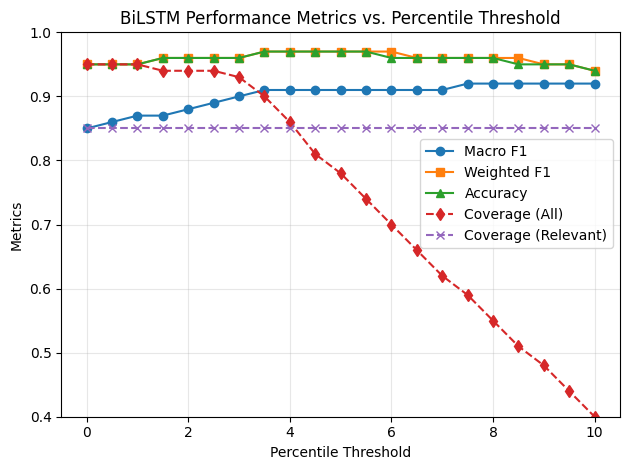

In [56]:
# assemble and display table
df = pd.DataFrame(results)
print(df)

# ——— plot all five metrics ———
plt.figure()
plt.plot(df['Threshold'], df['Macro F1'],             marker='o', label='Macro F1')
plt.plot(df['Threshold'], df['Weighted F1'],          marker='s', label='Weighted F1')
plt.plot(df['Threshold'], df['Accuracy'],             marker='^', label='Accuracy')
plt.plot(df['Threshold'], df['Coverage All'],       marker='d', linestyle='--', label='Coverage (All)')
plt.plot(df['Threshold'], df['Coverage Relevant'], marker='x', linestyle='--', label='Coverage (Relevant)')

plt.xlabel('Percentile Threshold')
plt.ylabel('Metrics')
plt.title('BiLSTM Performance Metrics vs. Percentile Threshold')
plt.legend(
    loc='center right',
    bbox_to_anchor=(1.0, 0.58),  # x=1.0 (right edge), y=0.8 (80% up)
    fontsize=10
)
plt.grid(alpha=0.3)
plt.ylim(0.40, 1.0)
plt.tight_layout()
plt.savefig('lstm_gmm_full_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [57]:
entry = next(r for r in results if r['Threshold']==7.5)
y_true = entry['y_true_kept']
y_pred = entry['y_pred_kept']

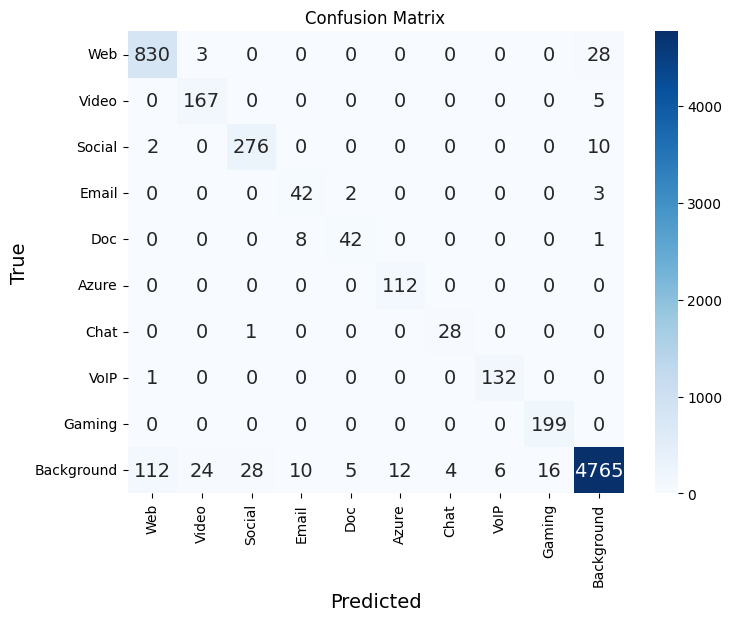

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_true, y_pred)
conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Azure","Chat","VoIP","Gaming","Background"]
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws={"size": 14})
# ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
# for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.savefig('gmm_fsnet_10classes.png', dpi=300, bbox_inches='tight')
plt.show()

In [86]:
log_prob_train = gmm10._estimate_log_prob(all_features)       # shape (N_train, K)
log_prob_test  = gmm10._estimate_log_prob(test_features)      # shape (N_test,  K)
log_weights    = np.log(gmm10.weights_)                       # shape (K,)

joint_ll_train = log_prob_train + log_weights[None, :]        # (N_train, K)
joint_ll_test  = log_prob_test  + log_weights[None, :]        # (N_test,  K)

# 2) get the GMM’s cluster assignment (predicted) for each point
cluster_train = joint_ll_train.argmax(axis=1)  # which Gaussian wins for each train sample
cluster_test  = joint_ll_test.argmax(axis=1)   # which Gaussian wins for each test sample

In [47]:
y_test_arr     = np.array(y_test)
labels_train   = np.array(labels_train)   # true train labels (for mapping to fixed_pct_class9)
labels_test    = np.array(labels_test)    # true test labels (for final evaluation)

# thresholds       = list(range(0, 26))
thresholds = [
    0.0,  0.5,  1.0,  1.5,  2.0,
    2.5,  3.0,  3.5,  4.0,  4.5,
    5.0,  5.5,  6.0,  6.5,  7.0,
    7.5,  8.0,  8.5,  9.0,  9.5,
    10.0
]
fixed_pct_class9 = 25
default_class    = 10

results = []
for t in thresholds:
    # 3) build per‑cluster cutoff on TRAINING samples, _grouped by cluster_train_
    pct_cutoff = {}
    for k in range(gmm10.n_components):
        idxs = np.where(cluster_train == k)[0]
        if len(idxs) == 0:
            pct_cutoff[k] = None
            continue

        # find which true class this cluster corresponds to (if any)
        # so you can still apply your special 25th percentile for class 9
        # else sweep t for other clusters
        # NB: cluster_label_map maps cluster k → class label (e.g. 9)
        mapped_lbl = cluster_label_map.get(k, None)
        pct = fixed_pct_class9 if mapped_lbl == 9 else t

        # take the percentile of joint_ll_train[idxs, k]
        pct_cutoff[k] = np.percentile(joint_ll_train[idxs, k], pct)

    # 4) threshold TEST samples by their assigned cluster
    N_test = joint_ll_test.shape[0]
    y_pred = np.full(N_test, default_class, dtype=int)

    # pull out each test point's log‑likelihood in its assigned cluster
    assigned_ll = joint_ll_test[np.arange(N_test), cluster_test]

    for i in range(N_test):
        k = cluster_test[i]
        cutoff = pct_cutoff.get(k)
        if cutoff is not None and assigned_ll[i] >= cutoff:
            y_pred[i] = cluster_label_map[k]

    # 5) compute metrics on the “kept” subset if you want, and also overall coverage
    keep_mask = (y_pred != default_class)
    if keep_mask.any():
        yt = y_test_arr[keep_mask]
        yp = y_pred[keep_mask]
        macro    = f1_score(yt, yp, average='macro')
        weighted = f1_score(yt, yp, average='weighted')
        acc_sub  = accuracy_score(yt, yp)
    else:
        macro = weighted = acc_sub = np.nan

    # coverage: fraction of all test points correctly classified
    correct = (y_pred == y_test_arr)
    coverage_all = correct.sum() / len(y_test_arr)

    # coverage ignoring true‑class‑9 points (if that matters)
    non9 = (y_test_arr != 9)
    coverage_rel = (correct & non9).sum() / non9.sum()

    results.append({
        'Threshold':           t,
        'Macro F1':            round(macro,    2),
        'Weighted F1':         round(weighted, 2),
        'Accuracy':     round(acc_sub,  2),
        'Coverage All':        round(coverage_all, 2),
        'Coverage Relevant':   round(coverage_rel,  2)
    })

NameError: name 'cluster_train' is not defined

    Threshold  Macro F1  Weighted F1  Accuracy  Coverage All  \
0           0      0.90         0.97      0.97          0.89   
1           1      0.91         0.97      0.97          0.88   
2           2      0.92         0.97      0.97          0.88   
3           3      0.92         0.97      0.97          0.88   
4           4      0.92         0.98      0.98          0.88   
5           5      0.93         0.98      0.98          0.87   
6           6      0.93         0.98      0.98          0.87   
7           7      0.93         0.98      0.98          0.87   
8           8      0.93         0.98      0.98          0.87   
9           9      0.93         0.98      0.98          0.87   
10         10      0.93         0.98      0.98          0.87   
11         11      0.93         0.98      0.98          0.86   
12         12      0.93         0.98      0.98          0.86   
13         13      0.93         0.98      0.98          0.86   
14         14      0.94         0.98    

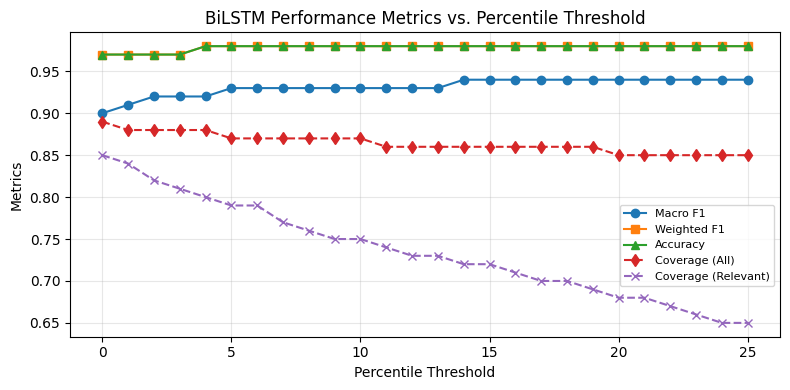

In [90]:
# assemble and display table
df = pd.DataFrame(results)
print(df)

# ——— plot all five metrics ———
plt.figure(figsize=(8,4))
plt.plot(df['Threshold'], df['Macro F1'],             marker='o', label='Macro F1')
plt.plot(df['Threshold'], df['Weighted F1'],          marker='s', label='Weighted F1')
plt.plot(df['Threshold'], df['Accuracy'],             marker='^', label='Accuracy')
plt.plot(df['Threshold'], df['Coverage All'],       marker='d', linestyle='--', label='Coverage (All)')
plt.plot(df['Threshold'], df['Coverage Relevant'], marker='x', linestyle='--', label='Coverage (Relevant)')

plt.xlabel('Percentile Threshold')
plt.ylabel('Metrics')
plt.title('BiLSTM Performance Metrics vs. Percentile Threshold')
plt.legend(
    loc='center right',
    bbox_to_anchor=(1.0, 0.3),   # x=1.0 stays at right edge, y=0.3 lowers it
    fontsize=8
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_full_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [84]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
macro_f1 = round(f1_score(y_test, y_pred2, average='macro'), 2)
accuracy = round(accuracy_score(y_test, y_pred2), 2)
average_f1 = round(f1_score(y_test, y_pred2, average='weighted'), 2)
# precision = precision_score(y_test_categorical, y_pred, average=None)
# recall = recall_score(y_test_categorical, y_pred, average=None)
f1 = f1_score(y_test, y_pred2, average=None)
conf_matrix = confusion_matrix(y_test, y_pred2)

# Print or use the evaluation metrics as needed
print(f'Macro Average F1 Score: {macro_f1}')
print(f'Accuracy: {accuracy}')
print(f'Weighted Average F1 Score: {average_f1}')

Macro Average F1 Score: 0.7
Accuracy: 0.85
Weighted Average F1 Score: 0.91


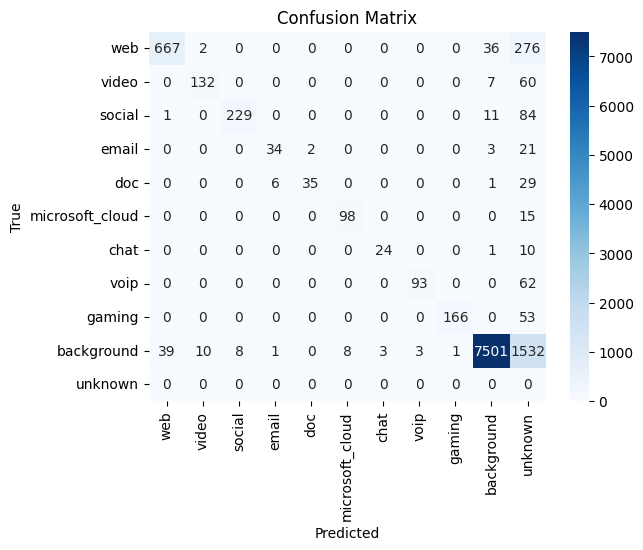

In [71]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred2)

# Visualize confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['web','video','social','email','doc','microsoft_cloud','chat','voip','gaming','background','unknown'], yticklabels=['web','video','social','email','doc','microsoft_cloud','chat','voip','gaming','background','unknown'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [139]:
y_pred2=np.array(y_pred2)

In [140]:
np.unique(y_pred2)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [141]:
total = len(y_test)
total_flows = 0
for cls in np.unique(y_test):
    idx       = np.where(y_test == cls)[0]
    count_i   = len(idx)
    correct_i = np.sum(y_pred2[idx] == cls)
    acc_i     = 100 * correct_i / count_i
    print(f"Label {cls}: {count_i}/{total} flows,  {correct_i}/{count_i} covered  ({acc_i:.2f}%)")
    total_flows+=correct_i

print(f"\nOverall: {total_flows}/{total} covered  ({100*total_flows/total:.2f}%)")

Label 0: 981/11264 flows,  777/981 covered  (79.20%)
Label 1: 199/11264 flows,  158/199 covered  (79.40%)
Label 2: 325/11264 flows,  260/325 covered  (80.00%)
Label 3: 60/11264 flows,  39/60 covered  (65.00%)
Label 4: 71/11264 flows,  40/71 covered  (56.34%)
Label 5: 113/11264 flows,  107/113 covered  (94.69%)
Label 6: 35/11264 flows,  27/35 covered  (77.14%)
Label 7: 155/11264 flows,  116/155 covered  (74.84%)
Label 8: 219/11264 flows,  187/219 covered  (85.39%)
Label 9: 9106/11264 flows,  8141/9106 covered  (89.40%)

Overall: 9852/11264 covered  (87.46%)


/tmp/ipykernel_3159208/1421336308.py:1: RuntimeWarning: invalid value encountered in divide
  conf_matrix_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100


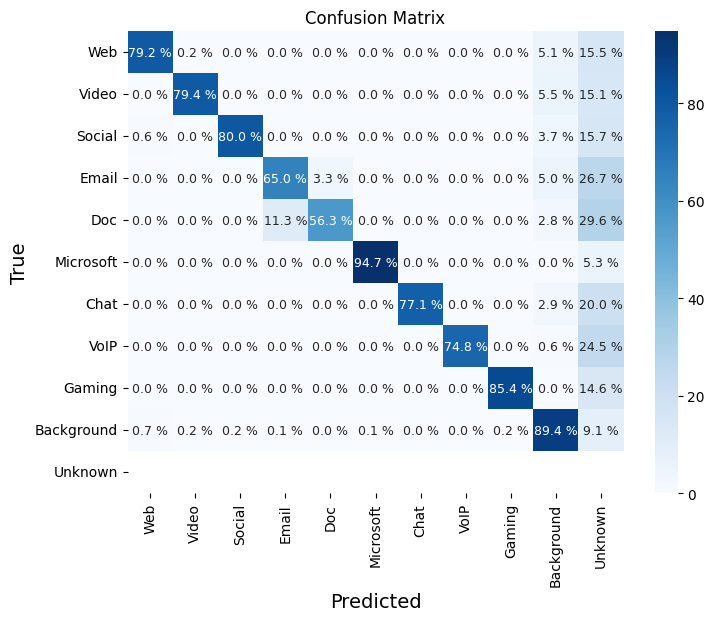

In [142]:
conf_matrix_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Microsoft","Chat","VoIP","Gaming","Background","Unknown"]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
annot_kws = {"size": 9}
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws=annot_kws)
for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)  
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.show()

In [143]:
y_pred2 = np.array(y_pred2)

In [144]:
domain_name = np.array(domain_name)

In [145]:
unknown_idx = 10
# build a boolean mask for all predictions that are NOT "unknown"
mask = (y_pred2 != unknown_idx)
y_test = np.array(y_test)
# apply it to both ground‐truth and prediction arrays
y_true_masked = y_test[mask]
y_pred_masked = y_pred2[mask]
domain_name_masked = domain_name[mask]
# now compute metrics on the filtered set
macro_f1       = round(f1_score(y_true_masked, y_pred_masked, average='macro'), 2)
accuracy       = round(accuracy_score(y_true_masked, y_pred_masked), 2)
weighted_f1    = round(f1_score(y_true_masked, y_pred_masked, average='weighted'), 2)
per_class_f1   = f1_score(y_true_masked, y_pred_masked, average=None)
conf_matrix    = confusion_matrix(y_true_masked, y_pred_masked)

print(f'Macro F1:   {macro_f1}')
print(f'Accuracy:   {accuracy}')
print(f'Weighted F1:{weighted_f1}')


Macro F1:   0.93
Accuracy:   0.98
Weighted F1:0.98


In [146]:
len(domain_name_masked)

10083

In [147]:
len(y_pred_masked)

10083

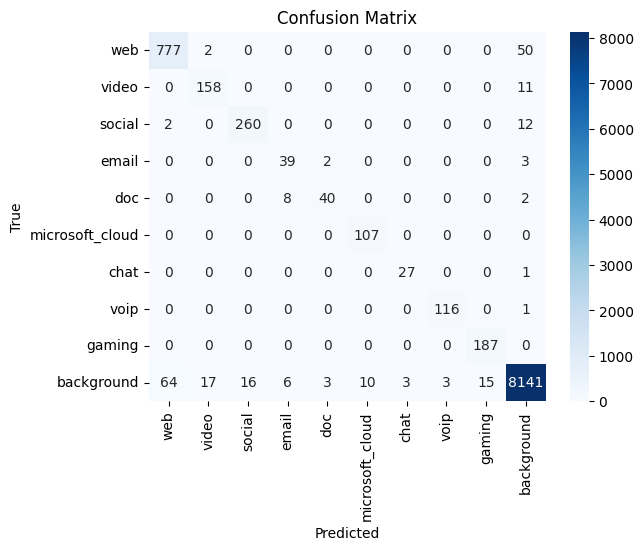

In [148]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_true_masked, y_pred_masked)

# Visualize confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['web','video','social','email','doc','microsoft_cloud','chat','voip','gaming','background'], yticklabels=['web','video','social','email','doc','microsoft_cloud','chat','voip','gaming','background'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

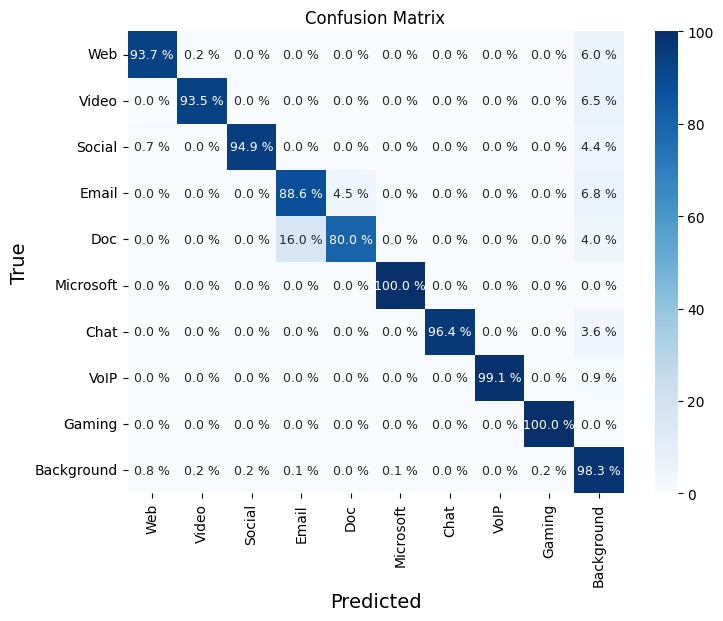

In [149]:
conf_matrix_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Microsoft","Chat","VoIP","Gaming","Background"]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
annot_kws = {"size": 9}
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws=annot_kws)
for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)  
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.show()